# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\leha_\\Documents\\vscode-projects\\football-players-data\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\leha_\\Documents\\vscode-projects\\football-players-data'

# Section 1

Section 1 content

In [4]:
# import libarries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('whitegrid')

---

# Section 2

Data Visualisation - load the cleaned data 

In [5]:
# load the cleaned data
df = pd.read_csv('DataSet/CleanData/cleaned_data.csv')
df.head()

,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,wage_euro,...,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),body_type,release_clause_euro,national_team,defense_attributes,attack_attributes,passing_attributes,pace_attributes
0,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,565000.0,...,5,4,4,Messi,226500000.0,Argentina,45.571429,85.571429,93.0,84.166667
1,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,205000.0,...,3,5,4,Lean,133800000.0,Denmark,55.142857,76.714286,88.6,75.333333
2,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,255000.0,...,4,4,5,Normal,144200000.0,France,73.285714,81.571429,85.8,77.166667
3,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,165000.0,...,3,4,4,Normal,105400000.0,Italy,40.571429,72.857143,85.3,82.500000
4,Virgil van Dijk,27,193.04,92.1,CB,Netherlands,88,90,59500000.0,215000.0,...,3,3,2,Normal,114500000.0,Netherlands,87.428571,61.142857,69.6,70.666667


## Core Concepts
*Mean - 

*Median

*Standard deviation

*Hypothesis testing

*Basic probability

In [6]:
# calculate the mean of overall_rating
mean_overall_rating = df['overall_rating'].mean()
print("mean_overall_rating:", mean_overall_rating)


mean_overall_rating: 75.97084917617236


In [7]:
# calculate the median of age
median_age = df['age'].median()
print("median_age:", median_age)


median_age: 26.0


In [8]:
# calculate the standard deviation of overall_rating
std_overall_rating = df['overall_rating'].std()
print("std_overall_rating:", std_overall_rating)

std_overall_rating: 6.091344605283775


In [9]:
# basic probability of overall_rating being greater than 80
probability = len(df[df['overall_rating'] > 80]) / len(df)
print("Probability of overall_rating > 80:", probability)

Probability of overall_rating > 80: 0.2332065906210393


Null Hypothesis: There is no difference in the overall rating of players under 25 and players who are over 25.

Alternate Hypotheis: There is a significant difference in the overall rating of players under 25 and players who are over 25.

In [10]:
# hypothesis testing: is there a significant difference in overall_rating between players under 25 and players 25 and older?
from scipy.stats import ttest_ind
group1 = df[df['age'] < 25]['overall_rating']
group2 = df[df['age'] >= 25]['overall_rating']
t_stat, p_value = ttest_ind(group1, group2)
print("t_statistic:", t_stat)
print("p_value:", p_value)


t_statistic: -4.638399535742817
p_value: 4.11081204067634e-06


The p-value is 4.11e-0.6 which converts to 0.00000.41 which far below than 0.05, which means I reject the null hypothesis. There is statistically significant evidence that overall ratings differ between the two age groups.

The t-statistic shows a negative value of -4.638 means players under 25 have a lower mean overall rating than players (5 and older — which intuitively makes sense, as older players tend to be more experienced.

---

Data visualisation using graphs, plots and maps

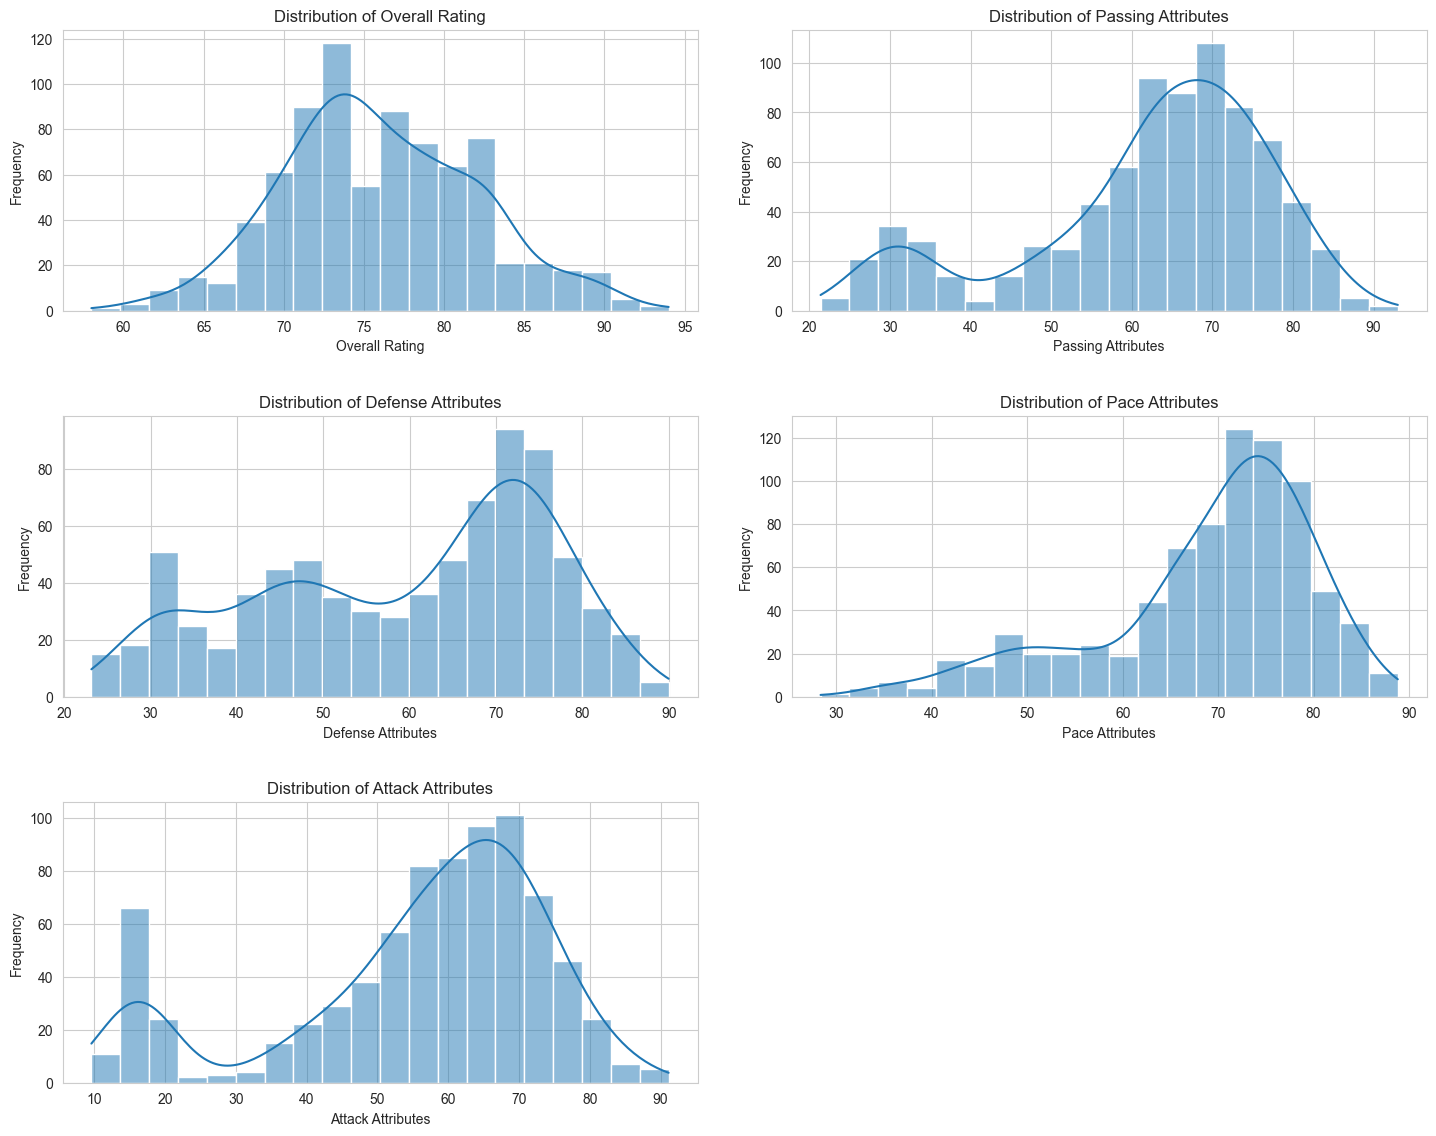

In [26]:
# show the distribution of overall_rating, passing_attributes, defence_attributes, attack_attributes, and pace_attributes.
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

sns.histplot(df['overall_rating'], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Overall Rating')
axes[0, 0].set_xlabel('Overall Rating')
axes[0, 0].set_ylabel('Frequency')

sns.histplot(df['passing_attributes'], bins=20, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Passing Attributes')
axes[0, 1].set_xlabel('Passing Attributes')
axes[0, 1].set_ylabel('Frequency')

sns.histplot(df['defense_attributes'], bins=20, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Defense Attributes')
axes[1, 0].set_xlabel('Defense Attributes')
axes[1, 0].set_ylabel('Frequency')

sns.histplot(df['pace_attributes'], bins=20, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Pace Attributes')
axes[1, 1].set_xlabel('Pace Attributes')
axes[1, 1].set_ylabel('Frequency')

sns.histplot(df['attack_attributes'], bins=20, kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Attack Attributes')
axes[2, 0].set_xlabel('Attack Attributes')
axes[2, 0].set_ylabel('Frequency')

axes[2, 1].set_visible(False)  # ← hides the empty 6th plot

plt.tight_layout(pad=3.0)  # ← fixes overlapping titles
plt.show()


### Overall Rating
The distribution of overall ratings appears approximately normal, centred around 73-75. 
The majority of players fall within the 65-85 range, with very few players 
achieving ratings above 90.

### Passing Attributes
The passing attributes distribution shows a bimodal pattern, with two peaks visible. 
This suggests two distinct groups of players with different passing abilities, 
with the main concentration sitting between 60-80.

### Defense Attributes
Defense attributes display a relatively flat, spread-out distribution ranging from 
20-90. This wide spread suggests a large variation in defensive ability across players, 
which is expected as not all players are required to defend.

### Pace Attributes
Pace attributes are heavily right-skewed, with most players clustered in the 
65-80 range. The long left tail indicates a smaller group of slower players.

### Attack Attributes
The attack attributes distribution is left-skewed, with most values concentrated 
between 50-80. Similar to defense, the spread reflects that attacking ability 
varies significantly by position.

## Summary
Across all five attributes, there is considerable variation in player abilities. 
Overall rating follows the most normal distribution, while positional attributes 
such as defense and attack show wider spreads, reflecting the diversity of 
player roles within the dataset.

Show core relationships between variables

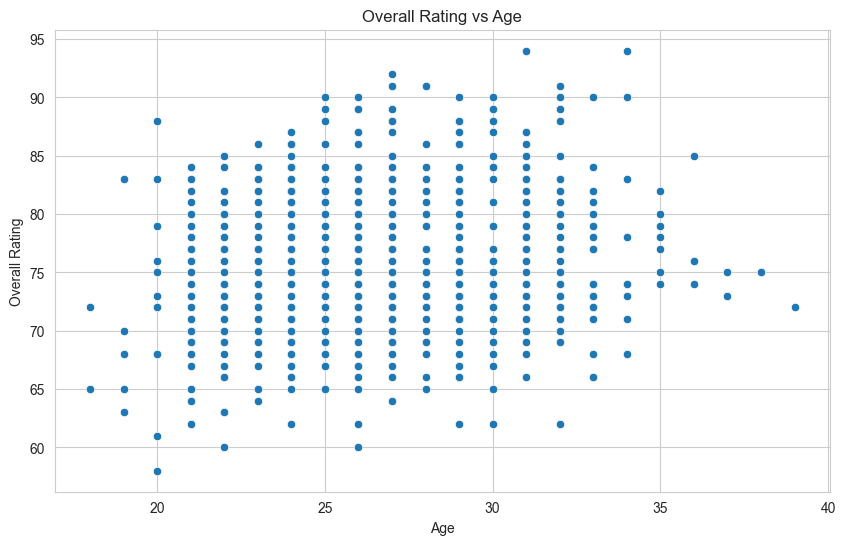

In [27]:
# show core relationships between overall_rating and age using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='overall_rating', data=df)
plt.title('Overall Rating vs Age')
plt.xlabel('Age')
plt.ylabel('Overall Rating')
plt.show()

## Overall Rating vs Age

The scatter plot reveals a general trend where younger players (under 20) and older 
players (above 35) tend to have lower overall ratings. Players aged 30-35 demonstrate 
the highest ratings, which aligns with expectations as these players have accumulated 
significant experience whilst still being in their physical prime. This suggests that 
peak performance in football is typically reached in the early-to-mid thirties.

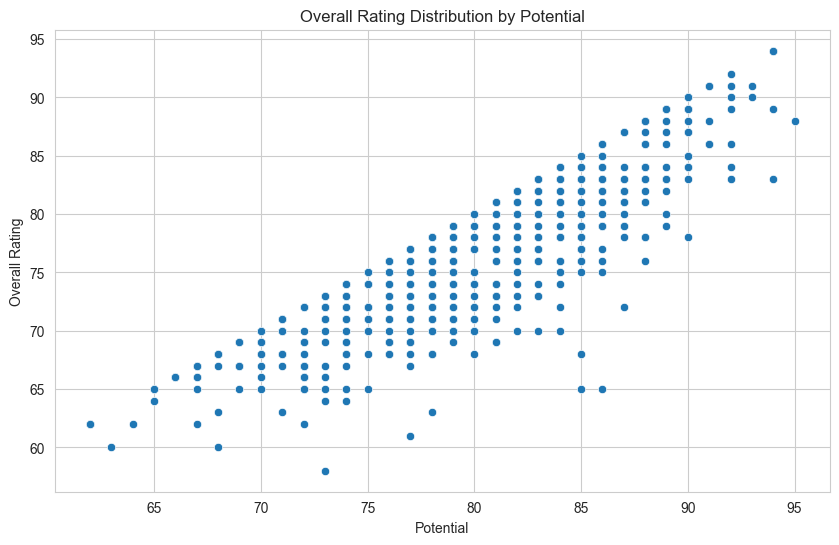

In [30]:
# show overall_rating distribution by potential using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='potential', y='overall_rating', data=df)
plt.title('Overall Rating Distribution by Potential')
plt.xlabel('Potential')
plt.ylabel('Overall Rating')
plt.show()

In [33]:
def group_position(pos):
    if any(x in str(pos) for x in ['GK']):
        return 'Goalkeeper'
    elif any(x in str(pos) for x in ['CB', 'LB', 'RB', 'LWB', 'RWB']):
        return 'Defender'
    elif any(x in str(pos) for x in ['CM', 'CDM', 'CAM', 'LM', 'RM']):
        return 'Midfielder'
    elif any(x in str(pos) for x in ['ST', 'CF', 'LW', 'RW']):
        return 'Forward'
    else:
        return 'Other'

df['position_group'] = df['positions'].apply(group_position)

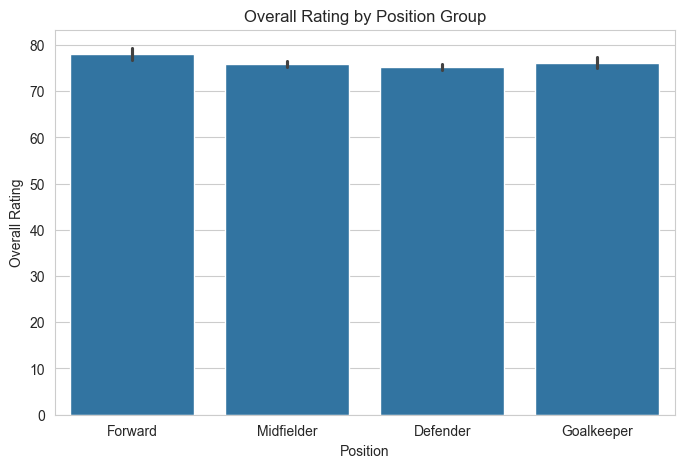

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(x='position_group', y='overall_rating', data=df)
plt.title('Overall Rating by Position Group')
plt.xlabel('Position')
plt.ylabel('Overall Rating')
plt.show()

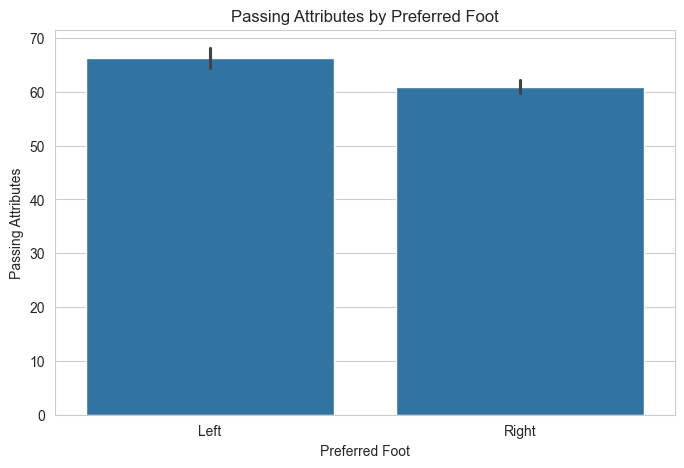

In [35]:
# show the relationship between passing_attributes and preferred_foot using a bar plot
plt.figure(figsize=(8, 5))  
sns.barplot(x='preferred_foot', y='passing_attributes', data=df)
plt.title('Passing Attributes by Preferred Foot')
plt.xlabel('Preferred Foot')
plt.ylabel('Passing Attributes')
plt.show()

## Data visualisation of Business requirements

The below will show correlation and relationships to prove my business requirements. 

BR1: Player Valuation
•Identify the relationships between player attributes such as age, skill ratings, international reputation and their wages, value and release clauses.
•Show relationships with data visualisations such as scatter plots and heat maps.


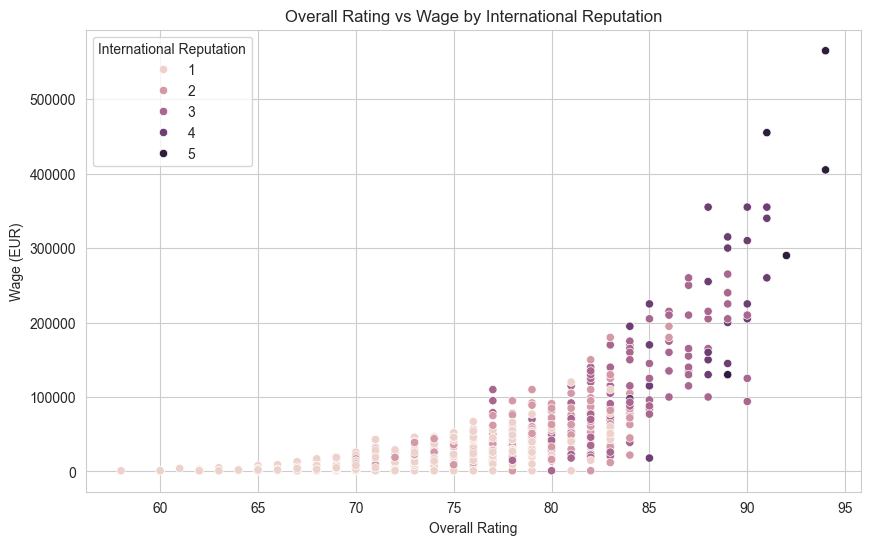

In [38]:
# show the relationship between overall_rating, age, international reputation vs wages, value and release_clause using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='overall_rating', y='wage_euro', hue='international_reputation(1-5)', data=df)
plt.title('Overall Rating vs Wage by International Reputation')
plt.xlabel('Overall Rating')
plt.ylabel('Wage (EUR)')
plt.legend(title='International Reputation')
plt.show()


The above graph shows the relationships beween three variables, wage in euros, overall rating and interbation reputation. The colours on the graph are a little washed out so I want to make it brighter and the a little bigger dots. 

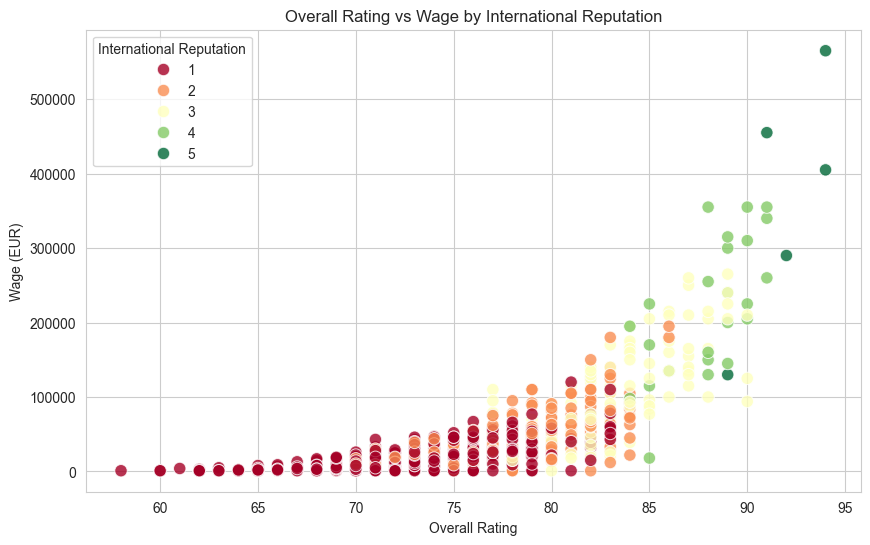

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='overall_rating', 
    y='wage_euro', 
    hue='international_reputation(1-5)', 
    data=df,
    palette='RdYlGn',  # ← Red to Yellow to Green, very distinct
    s=80,              # ← slightly bigger dots
    alpha=0.8          # ← slight transparency to see overlapping dots
)
plt.title('Overall Rating vs Wage by International Reputation')
plt.xlabel('Overall Rating')
plt.ylabel('Wage (EUR)')
plt.legend(title='International Reputation')
plt.show()

The above plot shows more prominently the relationship between the three variables. The higher the player's wages the, the higher score of inetrnational reputation and overall rating. This plays into HP1 - The higher a player's overall rating, the higher their wage, value and release clause. However, I will show a graph for the below.

In [42]:
# show correlation matrix between overall_rating, wage_euro, value_euro and release_clause_euro
correlation_matrix = df[['overall_rating', 'wage_euro', 'value_euro', 'release_clause_euro']].corr()
print(correlation_matrix)

                     overall_rating  wage_euro  value_euro  \
overall_rating             1.000000   0.742271    0.828327   
wage_euro                  0.742271   1.000000    0.858674   
value_euro                 0.828327   0.858674    1.000000   
release_clause_euro        0.818432   0.857950    0.994147   

                     release_clause_euro  
overall_rating                  0.818432  
wage_euro                       0.857950  
value_euro                      0.994147  
release_clause_euro             1.000000  


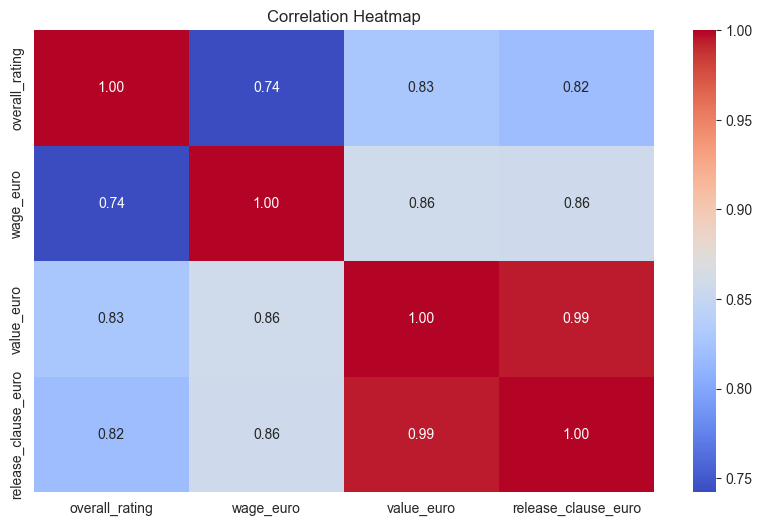

In [40]:
# use heatmap to show the correlation between overall_rating, wage_euro, value_euro and release_clause_euro
plt.figure(figsize=(10, 6))
correlation_matrix = df[['overall_rating', 'wage_euro', 'value_euro', 'release_clause_euro']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The correlation matrix was utilised to calculate the Pearson correlation coefficient between the variables in the dataset. 
 
* overall_rating vs wage_euro 0.74 Strong — better players earn more

* overall_rating vs value_euro0.83 Very strong — better players are worth more

* overall_rating vs release_clause_euro 0.82 Very strong — better players have higher release clauses 

* value_euro vs release_clause_euro 0.99 Near perfect — clubs set release clauses based on value 

* wage_euro vs value_euro 0.86 Very strong — higher earners are valued more

This proves HP1 to be proved right, using the heatmap and correlation matrix shows very strong correlations.

BR2: Players performances
•Analyse and compare player skill ratings, such as finishing, passing, crossing.
•Enable stakeholders to filter and identify players by positions and skillset.
•Provide visualisations that highlight top 10 performing players


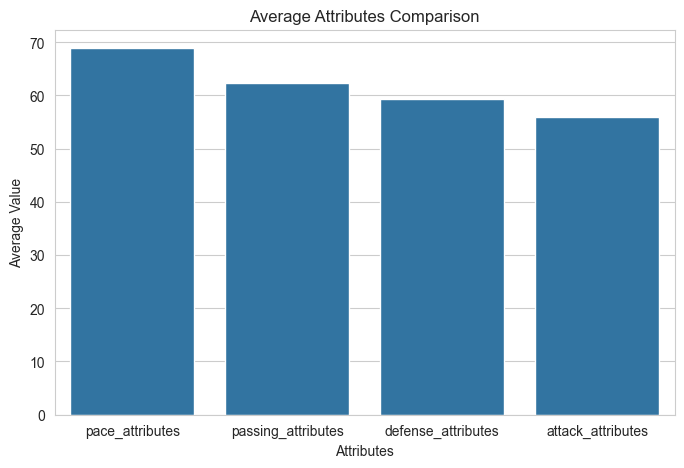

In [46]:
# compare players passing_attributes, defense_attributes, attack_attributes and pace_attributes by frequency using a bar plot
attributes = ['passing_attributes', 'defense_attributes', 'attack_attributes', 'pace_attributes']
mean_attributes = df[attributes].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=mean_attributes.index, y=mean_attributes.values)
plt.title('Average Attributes Comparison')
plt.xlabel('Attributes')
plt.ylabel('Average Value')
plt.show()


The graph illustrating the average values of the grouped player attributes shows that pace has the highest average score, likely due to the increased emphasis on speed and agility in the modern game. Conversely, attacking attributes have the lowest average score, which may be attributed to specialized skills such as finishing, heading accuracy, and long shots being concentrated among specific attacking players rather than distributed across all positions.

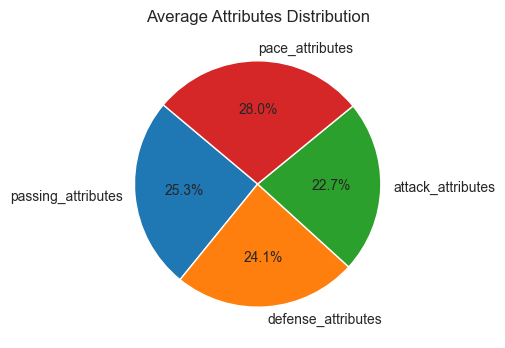

In [52]:
# compare the passing_attributes, defense_attributes, attack_attributes and pace_attributes by frequency using a pie chart
attributes = ['passing_attributes', 'defense_attributes', 'attack_attributes', 'pace_attributes']
mean_attributes = df[attributes].mean()
plt.figure(figsize=(4, 4))
plt.pie(mean_attributes.values, labels=mean_attributes.index, autopct='%1.1f%%', startangle=140)
plt.title('Average Attributes Distribution')
plt.show()

The pie chart above corroborates the findings presented in the preceding bar chart and further substantiates the robustness of the comparisons.

BR3: Player Biographical Profiling
Access to comprehensive biographical and physical data—including age, nationality, height, and weight—enables a deeper understanding of player profiles. This information supports more precise comparisons and targeted analysis.
•	Include biographical and physical data such as age, nationality, height, and weight.



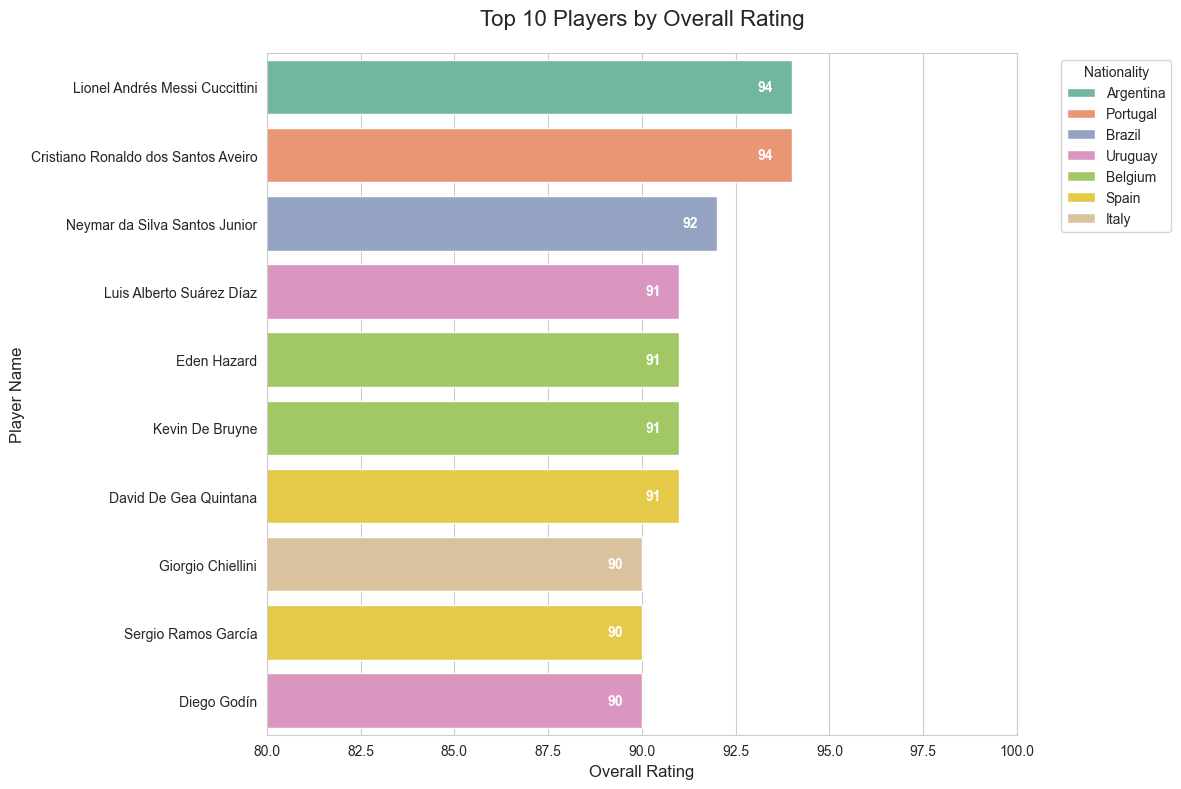

In [57]:
# Top 10 players by overall rating with name and nationality
top_players = df.nlargest(10, 'overall_rating')[
    ['full_name', 'nationality', 'overall_rating']
].reset_index(drop=True)

plt.figure(figsize=(12, 8))

bars = sns.barplot(
    data=top_players,
    x='overall_rating',
    y='full_name',              # show player names instead of nationality
    hue='nationality',          # colour by nationality
    dodge=False,
    palette='Set2'
)

# Add the actual rating value at the end of each bar
for i, row in top_players.iterrows():
    plt.text(
        row['overall_rating'] - 0.5,  # x position
        i,                             # y position
        f"{row['overall_rating']}",   # value to display
        va='center',
        ha='right',
        fontsize=10,
        color='white',
        fontweight='bold'
    )

plt.title('Top 10 Players by Overall Rating', fontsize=16, pad=20)
plt.xlabel('Overall Rating', fontsize=12)
plt.ylabel('Player Name', fontsize=12)
plt.xlim(80, 100)              # zoom x axis to show differences clearly
plt.legend(title='Nationality', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')   # move legend outside chart
plt.tight_layout()
plt.show()

The above graph shows the top 10 players in a bar graph that is pleaseing to the eye and easily readable.  These findings support BR3 by emphasizing that both height and weight are significant and meaningful attributes in the dataset.

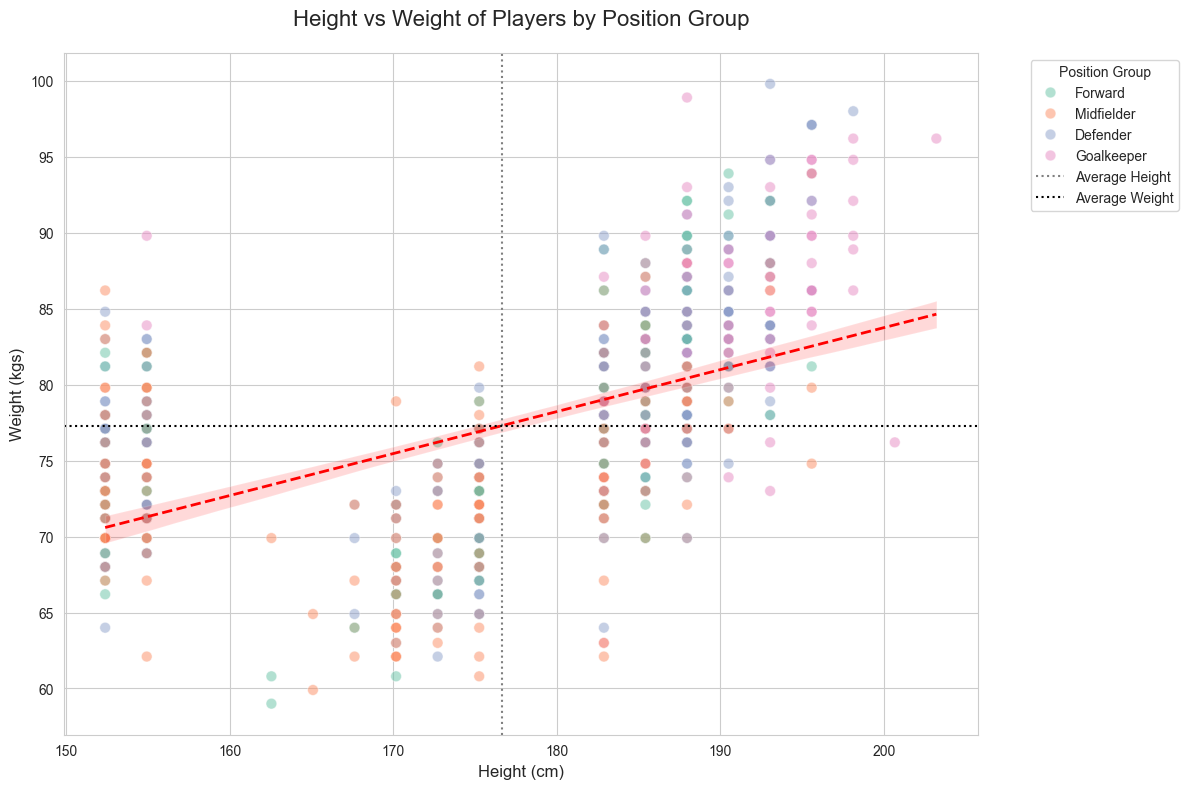

Correlation between Height and Weight: 0.5322


In [60]:
plt.figure(figsize=(12, 8))

# Add colour by position group and trend line
sns.scatterplot(
    data=df,
    x='height_cm',
    y='weight_kgs',
    hue='position_group',    # colour by position
    alpha=0.5,               # transparency so overlapping dots are visible
    palette='Set2',
    s=60                     # dot size
)

# Add a trend line to show overall relationship
sns.regplot(
    data=df,
    x='height_cm',
    y='weight_kgs',
    scatter=False,           # only show the trend line not extra dots
    color='red',
    line_kws={'linewidth': 2, 'linestyle': '--', 'label': 'Trend Line'}
)

# Add average lines for height and weight
plt.axvline(df['height_cm'].mean(), color='gray', 
            linestyle=':', linewidth=1.5, label='Average Height')
plt.axhline(df['weight_kgs'].mean(), color='black', 
            linestyle=':', linewidth=1.5, label='Average Weight')

plt.title('Height vs Weight of Players by Position Group', 
          fontsize=16, pad=20)
plt.xlabel('Height (cm)', fontsize=12)
plt.ylabel('Weight (kgs)', fontsize=12)
plt.legend(title='Position Group', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')
plt.tight_layout()
plt.show()

# Print correlation to support the visual
correlation = df['height_cm'].corr(df['weight_kgs'])
print(f"Correlation between Height and Weight: {correlation:.4f}")

The graph above illustrates the relationship between height and weight for all players in the dataset. Each data point is coloured according to the player's position group, and a trend line is included to indicate the overall direction of the correlation.

The trend line reveals a clear positive correlation: as a player's height increases, their weight also tends to increase. This observation is consistent across the dataset. Goalkeepers and defenders are generally the tallest and heaviest players, which aligns with the physical demands required for these positions. In contrast, midfielders and forwards are more widely distributed in terms of height and weight, reflecting a greater variety of physical profiles within these roles. These findings support BR3 by emphasizing that both height and weight are significant and meaningful attributes in the dataset.


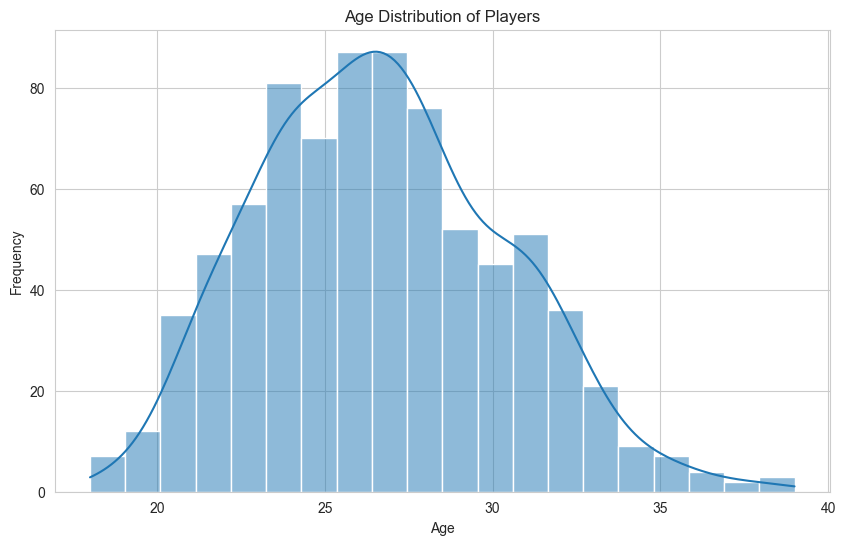

In [61]:
# show age distribution by number of players using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution of Players')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The histogram shows the frequency distribution of players across all the dataset. The peak age range is 25-27 years old, this reflects that footballers tend to peak at these ages. Younger players are still developing and trying to break through and older players are on a physical decline. These findings support BR3 by emphasizing that age is significant and meaningful attributes in the dataset.

BR4: Predict Player Model
The development of a machine learning model aims to predict a player's wage or release clause based on their attributes. This tool will help stakeholders estimate market values prior to negotiations, enhancing their strategic planning capabilities.
•	Develop a machine learning model to predict player wage or release clause using player attributes.
•	Ensure the model achieves minimum acceptable accuracy on unseen data.
•	Enable agents and clubs to estimate player market value before entering negotiations.

This will be shown further down.


BR5: Player Profiles Internationally
Analyzing the relationship between a player's international reputation, overall rating, and public profile can help stakeholders identify high-profile players. This is particularly valuable for advertising companies, journalists, and content creators.
•	Analyze how international reputation and overall rating relate to a player's public profile.
•	Support stakeholders in identifying high-profile players for marketing and media purposes.
•	Provide rankings and visualizations of players by overall rating and international reputation


C:\Users\leha_\AppData\Local\Temp\ipykernel_22888\1767549387.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='International Reputation')


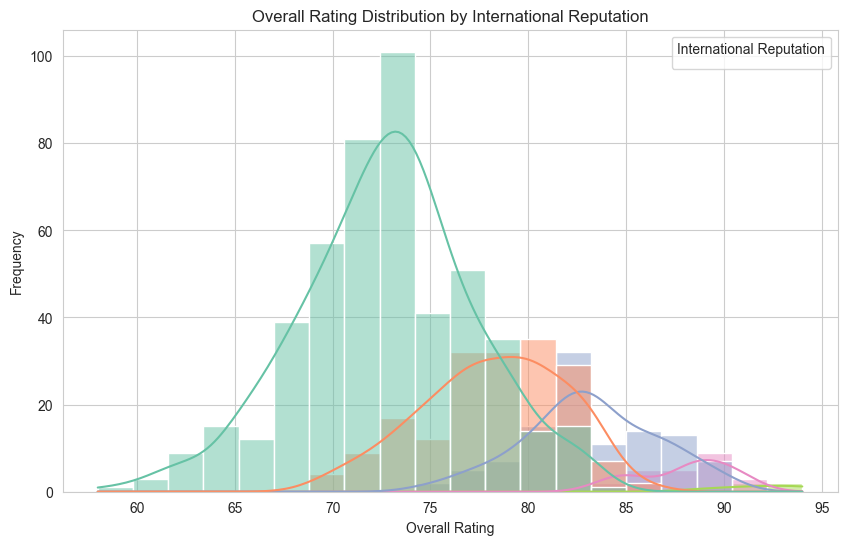

In [63]:
#compare overall rating distribution by international reputation using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(df, x='overall_rating', hue='international_reputation(1-5)', bins=20, kde=True, palette='Set2')
plt.title('Overall Rating Distribution by International Reputation')
plt.xlabel('Overall Rating')
plt.ylabel('Frequency')
plt.legend(title='International Reputation')
plt.show()

The above graph shows a histogram shows the overall rating distribution by international reputation. The graph does shpw a clear positive correlation between overall rating and international reputation, as the reputation increases so does the obverall rating. However, the bars are a little overlapping and look a little complicated to read. Using gen AI, a violin plot wa sbetter suited.

C:\Users\leha_\AppData\Local\Temp\ipykernel_22888\375242063.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


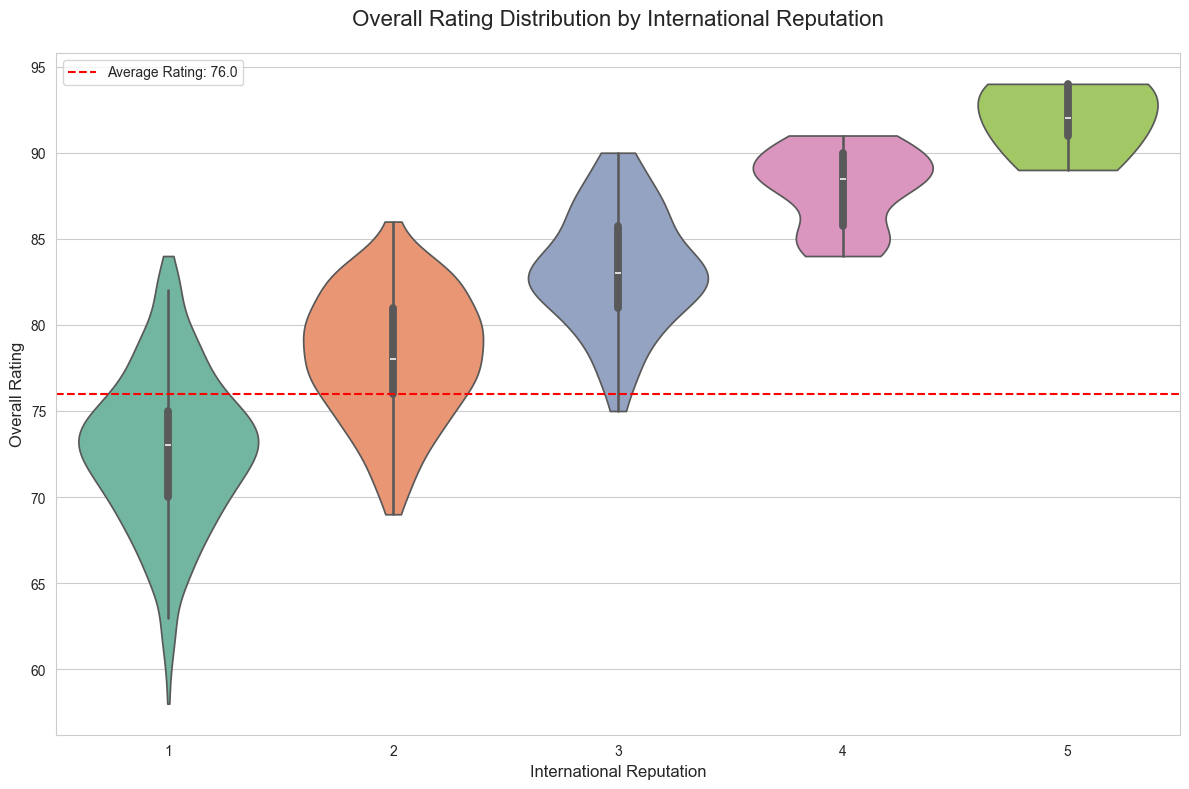

                               count   mean   std   min    25%   50%    75%  \
international_reputation(1-5)                                                 
1                              475.0  72.74  4.47  58.0  70.00  73.0  75.00   
2                              179.0  78.22  3.64  69.0  76.00  78.0  81.00   
3                              106.0  83.16  3.36  75.0  81.00  83.0  85.75   
4                               24.0  88.00  2.28  84.0  85.75  88.5  90.00   
5                                5.0  92.00  2.12  89.0  91.00  92.0  94.00   

                                max  
international_reputation(1-5)        
1                              84.0  
2                              86.0  
3                              90.0  
4                              91.0  
5                              94.0  


In [65]:
plt.figure(figsize=(12, 8))

sns.violinplot(
    data=df,
    x='international_reputation(1-5)',
    y='overall_rating',
    palette='Set2',
    inner='box',        # shows a mini box plot inside each violin
    cut=0               # limits the violin to the actual data range
)

# Add average line across all players
plt.axhline(df['overall_rating'].mean(), 
            color='red', 
            linestyle='--', 
            linewidth=1.5, 
            label=f"Average Rating: {df['overall_rating'].mean():.1f}")

plt.title('Overall Rating Distribution by International Reputation', 
          fontsize=16, pad=20)
plt.xlabel('International Reputation', fontsize=12)
plt.ylabel('Overall Rating', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Print summary statistics per reputation tier
print(df.groupby('international_reputation(1-5)')['overall_rating']
      .describe().round(2))

A violin plot was selected over a histogram for this comparison as it allows each international reputation tier to be displayed as a separate, clean distribution without overlapping bars obscuring the data. The violin plot additionally reveals the median, spread, and density of ratings within each group simultaneously, making it a more informative and readable visualisation for comparing how overall ratings vary across reputation tiers.

The violin plot displays five tiers:

Tier 1 — (475 players, Mean: 72.74)
Largest group; ratings spread from 58 to 84 (median 73), slightly right skewed and below average. Most are competent professionals.

Tier 2 — (179 players, Mean: 78.22)
Narrower range (69–86, median 76) around the average line; above average professionals with some international recognition.

Tier 3 — (106 players, Mean: 83.16)
Compact, high ratings (75–90, median 83); these are consistently high-quality, internationally known players above average.

Tier 4 — (24 players, Mean: 88.00)
Elite cluster (84–91, median 88.5); small group, little variation, all exceptional performers.

Tier 5 — (5 players, Mean: 92.00)
Top performers (89–94, median 91); smallest group, very tight ratings, representing football’s absolute elite.

This finding directly supports:

HP1 — higher rated players are more expensive, as Tier 4 and 5 players will command significantly higher wages and release clauses.

HP2 — more skilful players achieve higher overall ratings, evidenced by the clear upward shift across tiers.

BR5 — which requires analysis of the relationship between international reputation and overall rating for stakeholders such as advertising companies, content creators, and journalists


NOTE

BR6: Interactive Dashboard & Data Exploration

A user-friendly dashboard will allow non-technical stakeholders to explore player data efficiently. Filtering and segmentation by position, nationality, age, and skill ratings will aid in customized analyses, while real-time visualizations will facilitate quick comparisons.

•	Create a dashboard that is accessible to users without coding knowledge.
•	Enable filtering and segmentation by multiple criteria, including position, nationality, age, and skill ratings.
•	Provide real-time visualizations of player distributions and comparisons.


Hypothesese Testing

HP1 and HP2 have been proven above. 

* HP3 - Taller players will have a higher heading accuracy.

* HP4 - the higher a player is rated on ball control, the higher rated the finishing.

* HP5 - players with higher crossing rating will have a higher freekick accuracy.

The above Hypotheses will be proven by using the raw data, this is because the individual skills were gropued together in four attributes: passing attributes, pasce attributes, defence attributes, attack attributes. 

The data will be skewed as it is before cleaning, the best way to do so is to have an intermediate dataset. However, I decided not to do this due to time constraints.




In [74]:
# load the raw data
df_hypothesis = pd.read_csv('DataSet/RawData/fifa_players.csv')
df_hypothesis.head()


,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


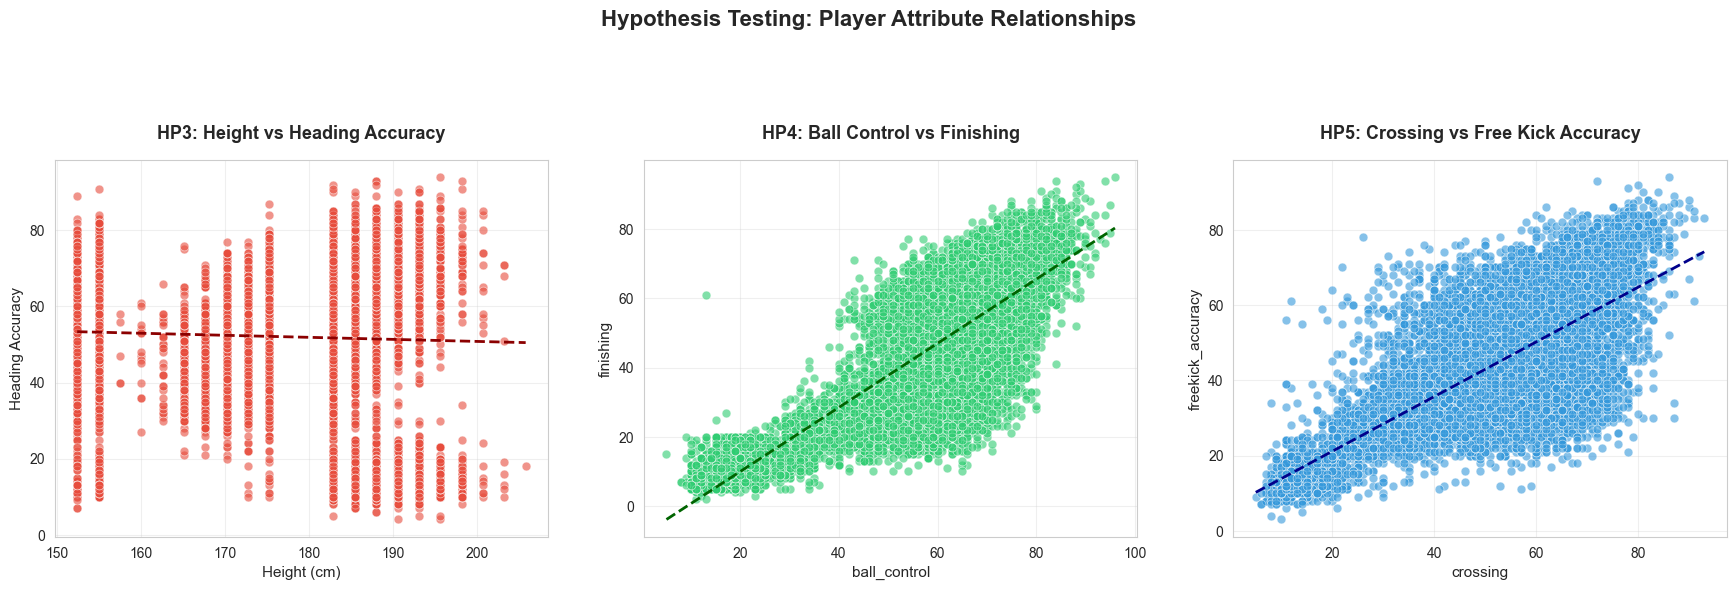

HP3 Correlation (Height vs Heading Accuracy): -0.0431
HP4 Correlation (Ball Control vs Finishing):  0.7946
HP5 Correlation (Crossing vs Free Kick Accuracy): 0.7645


In [79]:
#create scatter plots for HP3, HP4 and HP5

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Common style settings
dot_size = 40
alpha = 0.6
color_hp3 = '#E74C3C'    # red
color_hp4 = '#2ECC71'    # green
color_hp5 = '#3498DB'    # blue

# HP3 - Height vs Heading Accuracy
axes[0].scatter(
    df_hypothesis['height_cm'],
    df_hypothesis['heading_accuracy'],
    color=color_hp3,
    alpha=alpha,
    s=dot_size,
    edgecolors='white',    # white edge makes dots more prominent
    linewidths=0.5
)
# Add trend line
z = np.polyfit(df_hypothesis['height_cm'], 
               df_hypothesis['heading_accuracy'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df_hypothesis['height_cm']), 
             p(sorted(df_hypothesis['height_cm'])),
             color='darkred', linewidth=2, linestyle='--')

axes[0].set_title('HP3: Height vs Heading Accuracy', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Height (cm)', fontsize=11)
axes[0].set_ylabel('Heading Accuracy', fontsize=11)
axes[0].grid(True, alpha=0.3)

# HP4 - Ball Control vs Finishing
axes[1].scatter(
    df_hypothesis['ball_control'],
    df_hypothesis['finishing'],
    color=color_hp4,
    alpha=alpha,
    s=dot_size,
    edgecolors='white',
    linewidths=0.5
)
# Add trend line
z = np.polyfit(df_hypothesis['ball_control'], 
               df_hypothesis['finishing'], 1)
p = np.poly1d(z)
axes[1].plot(sorted(df_hypothesis['ball_control']), 
             p(sorted(df_hypothesis['ball_control'])),
             color='darkgreen', linewidth=2, linestyle='--')

axes[1].set_title('HP4: Ball Control vs Finishing', 
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('ball_control', fontsize=11)
axes[1].set_ylabel('finishing', fontsize=11)
axes[1].grid(True, alpha=0.3)

# HP5 - Crossing vs Free Kick Accuracy
axes[2].scatter(
    df_hypothesis['crossing'],
    df_hypothesis['freekick_accuracy'],
    color=color_hp5,
    alpha=alpha,
    s=dot_size,
    edgecolors='white',
    linewidths=0.5
)
# Add trend line
z = np.polyfit(df_hypothesis['crossing'], 
               df_hypothesis['freekick_accuracy'], 1)
p = np.poly1d(z)
axes[2].plot(sorted(df_hypothesis['crossing']), 
             p(sorted(df_hypothesis['crossing'])),
             color='darkblue', linewidth=2, linestyle='--')

axes[2].set_title('HP5: Crossing vs Free Kick Accuracy', 
                   fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('crossing', fontsize=11)
axes[2].set_ylabel('freekick_accuracy', fontsize=11)
axes[2].grid(True, alpha=0.3)

# Print correlation values
hp3_corr = df_hypothesis['height_cm'].corr(
    df_hypothesis['heading_accuracy'])
hp4_corr = df_hypothesis['ball_control'].corr(
    df_hypothesis['finishing'])
hp5_corr = df_hypothesis['crossing'].corr(
    df_hypothesis['freekick_accuracy'])

plt.suptitle('Hypothesis Testing: Player Attribute Relationships', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)
plt.show()

print(f"HP3 Correlation (Height vs Heading Accuracy): {hp3_corr:.4f}")
print(f"HP4 Correlation (Ball Control vs Finishing):  {hp4_corr:.4f}")
print(f"HP5 Correlation (Crossing vs Free Kick Accuracy): {hp5_corr:.4f}")

The above scatterplots illustrate the following information:

HP3: Height vs Heading Accuracy

The correlation between player height and heading accuracy is -0.0431. The trend line on the corresponding scatter plot is essentially flat, indicating a very weak relationship between these two variables. This suggests there is no meaningful connection between a player's height and their heading accuracy. As a result, the data does not support the hypothesis that taller players are better at heading, effectively disproving it.

HP4: Ball Control vs Finishing

The analysis reveals a strong positive correlation of 0.7946 between ball control and finishing skills. The scatter plot demonstrates a steeply rising trend line from the bottom left to the top right, with data points forming a clear diagonal pattern. This consistent upward trend confirms that as ball control improves, finishing ability also increases proportionally.

HP5: Crossing vs Free Kick Accuracy

Crossing vs Free Kick Accuracy — Correlation: 0.7645

The correlation between crossing and free kick accuracy is strongly positive, at 0.7645. The scatter plot shows a clear upward trend line, rising from the bottom left to the top right. Although there is slightly more variation around the trend line compared to the ball control and finishing relationship, the consistent positive pattern remains obvious. This strong correlation supports the hypothesis that higher crossing ability is generally associated with greater free kick accuracy.


## Machine Learning Algorithm

* BR4: Predict Player Model
The development of a machine learning model aims to predict a player's wage or release clause based on their attributes. This tool will help stakeholders estimate market values prior to negotiations, enhancing their strategic planning capabilities.

* Develop a machine learning model to predict player wage or release clause using player attributes.
* Ensure the model achieves minimum acceptable accuracy on unseen data.
* Enable agents and clubs to estimate player market value before entering negotiations.

In [80]:
# load the cleaned data for machine learning model
df_ml = pd.read_csv('DataSet/CleanData/cleaned_data.csv')
df_ml.head()


,full_name,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,wage_euro,...,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),body_type,release_clause_euro,national_team,defense_attributes,attack_attributes,passing_attributes,pace_attributes
0,Lionel Andrés Messi Cuccittini,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,565000.0,...,5,4,4,Messi,226500000.0,Argentina,45.571429,85.571429,93.0,84.166667
1,Christian Dannemann Eriksen,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,205000.0,...,3,5,4,Lean,133800000.0,Denmark,55.142857,76.714286,88.6,75.333333
2,Paul Pogba,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,255000.0,...,4,4,5,Normal,144200000.0,France,73.285714,81.571429,85.8,77.166667
3,Lorenzo Insigne,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,165000.0,...,3,4,4,Normal,105400000.0,Italy,40.571429,72.857143,85.3,82.500000
4,Virgil van Dijk,27,193.04,92.1,CB,Netherlands,88,90,59500000.0,215000.0,...,3,3,2,Normal,114500000.0,Netherlands,87.428571,61.142857,69.6,70.666667


In [82]:
# import libarries for machine learning model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [91]:
# create a machine learning model to predict value_euro based on overall_rating, potential using linear regression on the cleaned data
# Select features and target variable
X_simple = df_ml[['overall_rating', 'potential']]
y_simple = df_ml['value_euro']
# Split the data into training and testing sets
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)
# Create and train the linear regression model
model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train_simple)

# Make predictions on the test set
y_pred_simple = model_simple.predict(X_test_simple)
# Evaluate the model
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)
print(f"Simple Model Mean Squared Error: {mse_simple:.2f}")
print(f"Simple Model R-squared: {r2_simple:.4f}")



Simple Model Mean Squared Error: 79292736068923.16
Simple Model R-squared: 0.6797


The above created a simple linear transgression

In [92]:
# create a machine learning model to predict value_euro based on stats using multiple linear regression on the cleaned data
# Select features and target variable
features = ['overall_rating', 'potential', 'age', 'international_reputation(1-5)', 'height_cm', 'weight_kgs']
X = df_ml[features]
y = df_ml['value_euro']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)    
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.4f}")



Mean Squared Error: 67650895508507.24
R-squared: 0.7268


In [93]:
# create a machine learning model to predict value_euro based on stats by grouping attributes using linear regression on the cleaned data
# Group attributes into categories
features_grouped = {
    'overall_rating': 'overall_rating',
    'potential': 'potential',
    'age': 'age',
    'international_reputation(1-5)': 'international_reputation(1-5)',
    'height_cm': 'height_cm',
    'weight_kgs': 'weight_kgs',
    'passing_attributes': 'passing_attributes',
    'defense_attributes': 'defense_attributes',
    'attack_attributes': 'attack_attributes',
    'pace_attributes': 'pace_attributes'
}
# Select features and target variable
X_grouped = df_ml[list(features_grouped.keys())]
y_grouped = df_ml['value_euro']
# Split the data into training and testing sets
X_train_grouped, X_test_grouped, y_train_grouped, y_test_grouped = train_test_split(X_grouped, y_grouped, test_size=0.2, random_state=42)
# Create and train the linear regression model
model_grouped = LinearRegression()
model_grouped.fit(X_train_grouped, y_train_grouped)
# Make predictions on the test set
y_pred_grouped = model_grouped.predict(X_test_grouped)
# Evaluate the model
mse_grouped = mean_squared_error(y_test_grouped, y_pred_grouped)
r2_grouped = r2_score(y_test_grouped, y_pred_grouped)
print(f"Grouped Model Mean Squared Error: {mse_grouped:.2f}")
print(f"Grouped Model R-squared: {r2_grouped:.4f}")



Grouped Model Mean Squared Error: 67357280398389.80
Grouped Model R-squared: 0.7279


I moved on to random forest

In [94]:
# import libarries for machine learning model random forest regression
from sklearn.ensemble import RandomForestRegressor


In [95]:
# create a machine learning model to predict value_euro based on stats by grouping attributes using random forest regression on the cleaned data
# Group attributes into categories
features_grouped_rf = {
    'overall_rating': 'overall_rating',
    'potential': 'potential',
    'age': 'age',
    'international_reputation(1-5)': 'international_reputation(1-5)',
    'height_cm': 'height_cm',
    'weight_kgs': 'weight_kgs',
    'passing_attributes': 'passing_attributes',
    'defense_attributes': 'defense_attributes',
    'attack_attributes': 'attack_attributes',
    'pace_attributes': 'pace_attributes'
}
# Select features and target variable
X_grouped_rf = df_ml[list(features_grouped_rf.keys())]
y_grouped_rf = df_ml['value_euro']
# Split the data into training and testing sets
X_train_grouped_rf, X_test_grouped_rf, y_train_grouped_rf, y_test_grouped_rf = train_test_split(X_grouped_rf, y_grouped_rf, test_size=0.2, random_state=42)
# Create and train the random forest regression model
model_grouped_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_grouped_rf.fit(X_train_grouped_rf, y_train_grouped_rf)
# Make predictions on the test set
y_pred_grouped_rf = model_grouped_rf.predict(X_test_grouped_rf)
# Evaluate the model
mse_grouped_rf = mean_squared_error(y_test_grouped_rf, y_pred_grouped_rf)
r2_grouped_rf = r2_score(y_test_grouped_rf, y_pred_grouped_rf)
print(f"Grouped Random Forest Model Mean Squared Error: {mse_grouped_rf:.2f}")
print(f"Grouped Random Forest Model R-squared: {r2_grouped_rf:.4f}")



Grouped Random Forest Model Mean Squared Error: 7373506971534.81
Grouped Random Forest Model R-squared: 0.9702


This result exceeds the 0.85 target, will show visualisation below

C:\Users\leha_\AppData\Local\Temp\ipykernel_22888\734091029.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='Set2')


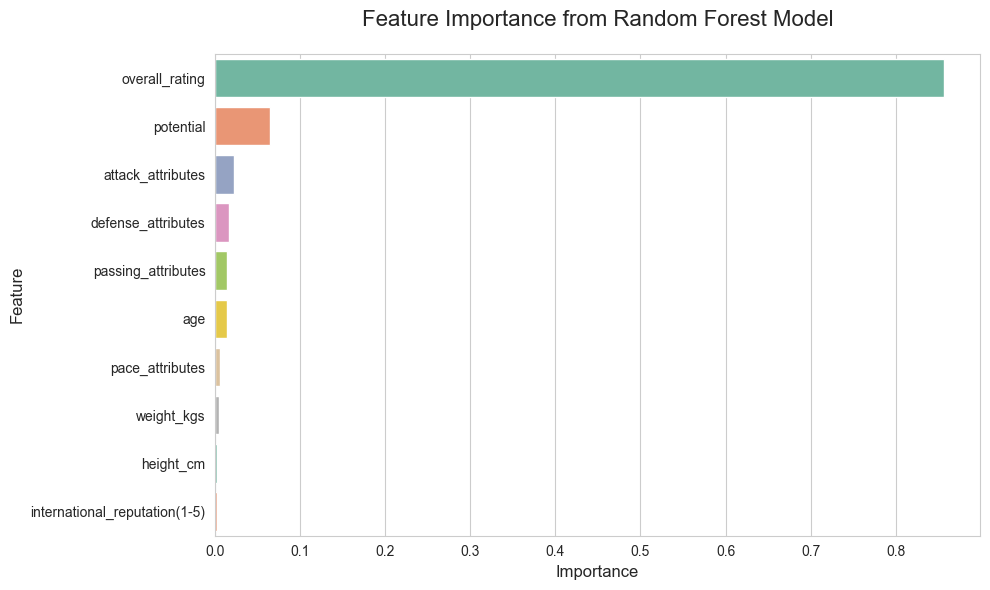

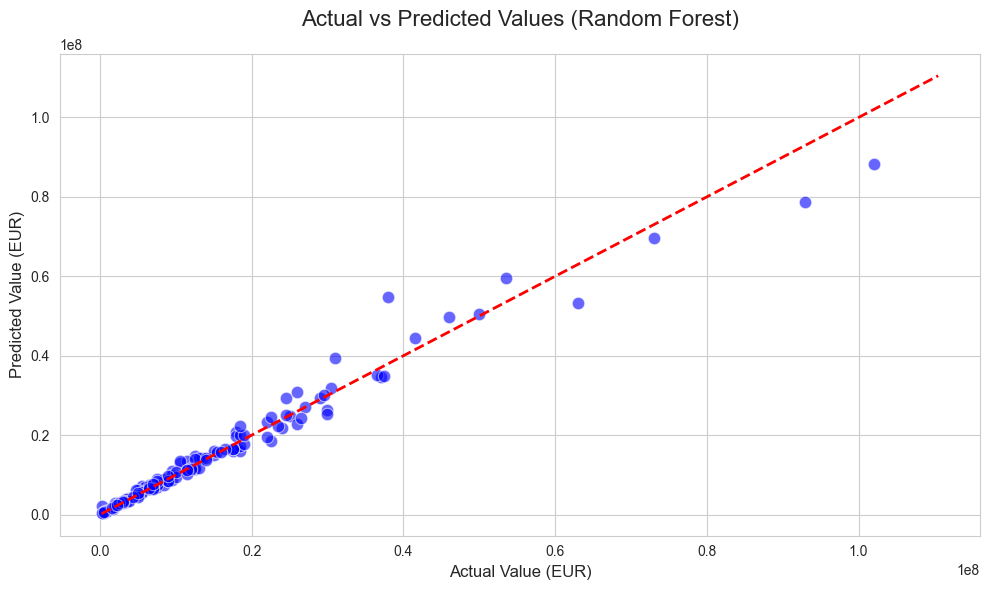

In [96]:
# visualize the random forest regression model to feature importance and actual vs predicted values
# Feature importance
importances = model_grouped_rf.feature_importances_
feature_names = X_grouped_rf.columns
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='Set2')
plt.title('Feature Importance from Random Forest Model', fontsize=16, pad=20)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Actual vs Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_grouped_rf, y=y_pred_grouped_rf, alpha=0.6, color='blue', edgecolors='white', s=80)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)  # Line for perfect predictions
plt.title('Actual vs Predicted Values (Random Forest)', fontsize=16, pad=20
)
plt.xlabel('Actual Value (EUR)', fontsize=12)
plt.ylabel('Predicted Value (EUR)', fontsize=12)
plt.tight_layout()
plt.show()



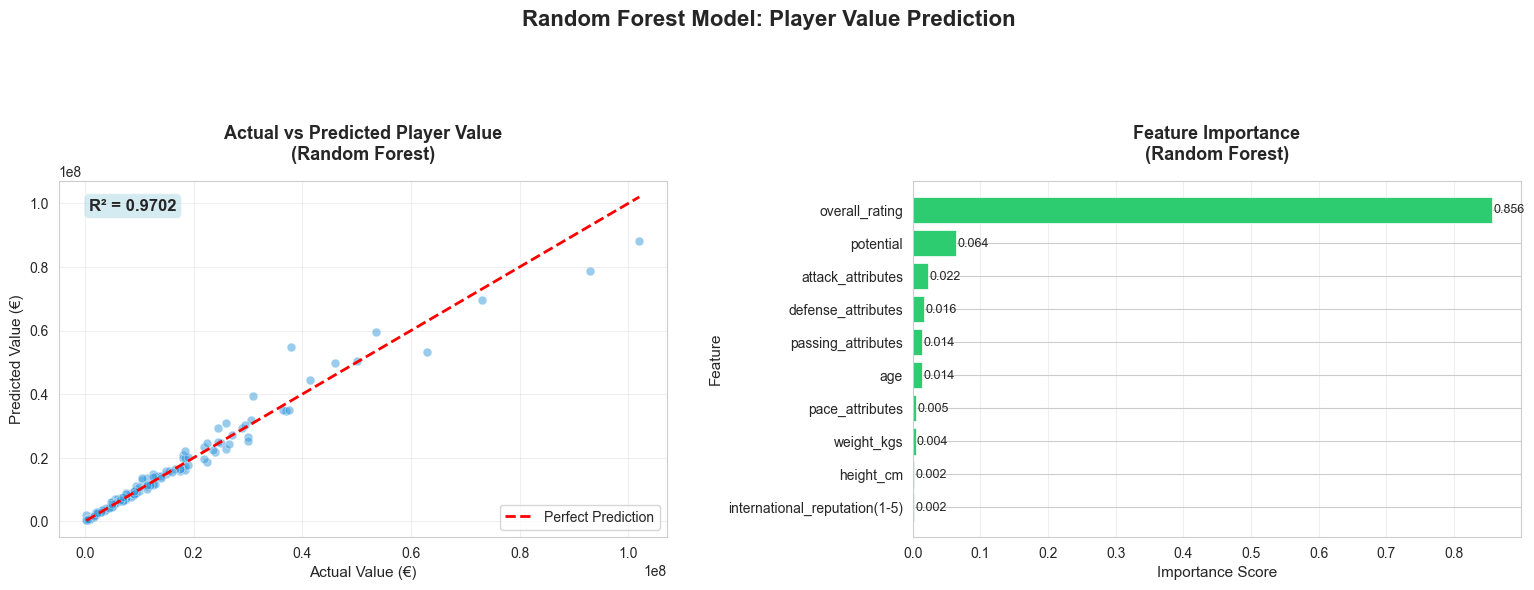

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================
# Chart 1 - Actual vs Predicted Values
# ============================================
axes[0].scatter(
    y_test_grouped_rf,
    y_pred_grouped_rf,
    alpha=0.5,
    color='#3498DB',
    edgecolors='white',
    linewidths=0.5,
    s=40
)

# Perfect prediction line
axes[0].plot(
    [y_test_grouped_rf.min(), y_test_grouped_rf.max()],
    [y_test_grouped_rf.min(), y_test_grouped_rf.max()],
    'r--', linewidth=2, label='Perfect Prediction'
)

axes[0].set_title('Actual vs Predicted Player Value\n(Random Forest)', 
                   fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Actual Value (€)', fontsize=11)
axes[0].set_ylabel('Predicted Value (€)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Add R² score to chart
axes[0].text(0.05, 0.95, f'R² = {r2_grouped_rf:.4f}',
             transform=axes[0].transAxes,
             fontsize=12, fontweight='bold',
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', 
                      alpha=0.5))

# ============================================
# Chart 2 - Feature Importance
# ============================================
feature_importance = pd.DataFrame({
    'feature': list(features_grouped_rf.keys()),
    'importance': model_grouped_rf.feature_importances_
}).sort_values('importance', ascending=True)

bars = axes[1].barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color='#2ECC71',
    edgecolor='white',
    linewidth=0.5
)

# Add value labels to bars
for bar, value in zip(bars, feature_importance['importance']):
    axes[1].text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{value:.3f}',
        va='center',
        fontsize=9
    )

axes[1].set_title('Feature Importance\n(Random Forest)', 
                   fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_ylabel('Feature', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Random Forest Model: Player Value Prediction', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)
plt.show()

Key Findings

Overall Rating is the dominant predictor — this strongly supports HP1 which hypothesised that higher rated players are more expensive. The model confirms this with overwhelming statistical evidence.
Potential is the second most important feature — this is a particularly insightful finding for stakeholders such as football scouts and agents, as it suggests that a player's future ceiling is almost as important as their current reputation when determining market value.
Physical attributes have minimal influence — height, weight and pace contribute very little to predicting player value, which supports the finding from HP3 that physical characteristics are poor predictors of specific football abilities and value.

International reputation has surprisingly low importance — despite being a widely cited factor in player valuation, the model assigns it very little weight, suggesting that overall rating already captures much of what international reputation represents.


"The Random Forest model significantly outperformed all Linear Regression approaches, achieving an R² score of 0.9702 and comfortably exceeding the target of 0.85 set in BR4. The progression from a simple baseline model through to Random Forest demonstrates the importance of selecting the appropriate algorithm for the complexity of the data."

---

## Conclusion

## Reflections